In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# !export PYDEVD_WARN_SLOW_RESOLVE_TIMEOUT=2

### Load packages and data

In [6]:
import spatialdata_io
import matplotlib.pyplot as plt
import spatialdata as sd
import segtraq
import spatialdata_plot
import scanpy as sc
import seaborn as sns
import anndata as ad
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import dask.dataframe as dd
import glob
from dask import delayed

from spatialdata.models import PointsModel
import statsmodels.api as sm
from pathlib import Path
from spatialdata.transformations import (
    get_transformation,
    set_transformation,
)

In [7]:
file = "../../data/proseg2.zarr"
sdata = sd.read_zarr(file)

no parent found for <ome_zarr.reader.Label object at 0x7fff4b50d750>: None
no parent found for <ome_zarr.reader.Label object at 0x7fff3e433490>: None
no parent found for <ome_zarr.reader.Label object at 0x7fff3f4fd110>: None
no parent found for <ome_zarr.reader.Label object at 0x7fff3e421490>: None
no parent found for <ome_zarr.reader.Label object at 0x7fff3e418fd0>: None
no parent found for <ome_zarr.reader.Label object at 0x7fff3e462a10>: None


In [8]:
st = segtraq.SegTraQ(
    sdata,
    images_key="image",
    points_background_id=0,
    tables_area_key=None,
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:116: UserWarning: Missing 4 cell IDs in shapes: [np.int64(11273), np.int64(10307), np.int64(10308), np.int64(6870)]... These cells are present in tables, but not in shapes. This might lead to inconsistencies in the spatialdata object.
  validate_spatialdata(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:1334: UserWarning: Duplicate IDs detected in index 'cell_id' for shapes 'nucleus_boundaries'. Resetting and renaming index to `segtraq_id` to ensure uniqueness.
  nucleus_shapes = _ensure_index(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:116: RuntimeWarning: No area column specified for tables. Area will be automatically computed from shapes.
  validate_spatialdata(


In [9]:
%%time
st.run_baseline()

CPU times: user 3.58 s, sys: 491 ms, total: 4.07 s
Wall time: 4.09 s


In [10]:
%%time
# recompute region similarity
st.rs.similarity_border_neighborhood()

CPU times: user 1min 43s, sys: 2.5 s, total: 1min 46s
Wall time: 1min 46s


,cell_id,similarity_center_border,similarity_border_neighborhood,ratio_border_neighborhood_to_center
0,1,0.232602,0.226166,0.972328
1,2,0.061235,0.000000,0.000000
2,3,NaN,NaN,NaN
3,4,0.085689,0.151357,1.766355
4,5,NaN,NaN,NaN
...,...,...,...,...
17542,17881,NaN,NaN,NaN
17543,17882,NaN,NaN,NaN
17544,17883,NaN,NaN,NaN
17545,17884,NaN,NaN,NaN


In [11]:
st.sdata['table']

AnnData object with n_obs × n_vars = 17885 × 5095
    obs: 'cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'volume', 'label_id', 'region', 'gene_count', 'mean_transcripts_per_gene', 'transcript_count', 'transcript_density', 'cell_area', 'perimeter', 'circularity', 'bbox_width', 'bbox_height', 'extent', 'solidity', 'convexity', 'elongation', 'eccentricity', 'compactness', 'num_polygons', 'similarity_center_border', 'similarity_border_neighborhood', 'ratio_border_neighborhood_to_center'
    var: 'total', 'unassigned', 'perc_unassigned'
    uns: 'spatialdata_attrs', 'num_cells', 'num_transcripts', 'num_genes', 'perc_unassigned_transcripts'
    layers: 'X_estimated'

In [12]:
features = ['similarity_center_border', 'similarity_border_neighborhood', 'ratio_border_neighborhood_to_center', 'transcript_count']
cell_df = []
obs = sdata.tables['table'].obs[features].copy()
obs['sample'] = "proseg2"
cell_df.append(obs)
cell_df = pd.concat(cell_df)
print(cell_df.shape)
cell_df = cell_df.reset_index(drop=True)
cell_df.head()

(17885, 5)


,similarity_center_border,similarity_border_neighborhood,ratio_border_neighborhood_to_center,transcript_count,sample
0,0.232602,0.226166,0.972328,535.0,proseg2
1,0.061235,0.000000,0.000000,48.0,proseg2
2,NaN,NaN,NaN,6.0,proseg2
3,0.085689,0.151357,1.766355,150.0,proseg2
4,NaN,NaN,NaN,47.0,proseg2


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

def plot_rs_against_counts(xcol, ycols):

    ycols = ycols

    plot_df = cell_df.replace([np.inf, -np.inf], np.nan).dropna(subset=[xcol] + ycols)
    plot_df = plot_df[plot_df[xcol] >= 0]

    samples = sorted(plot_df["sample"].unique())

    n_rows = len(samples)
    n_cols = len(ycols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4 * n_cols, 3 * n_rows),
        sharex=False,
        sharey=False
    )

    # handle case with only one sample
    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, sample in enumerate(samples):

        df_sample = plot_df[plot_df["sample"] == sample]

        for j, ycol in enumerate(ycols):

            ax = axes[i, j]

            sns.scatterplot(
                data=df_sample,
                x=xcol,
                y=ycol,
                alpha=0.25,
                s=10,
                linewidth=0,
                ax=ax,
                color="black"
            )

            # regression per sample
            X = sm.add_constant(df_sample[xcol].to_numpy())
            y = df_sample[ycol].to_numpy()

            if len(X) > 1:
                model = sm.OLS(y, X, missing="drop").fit()
                r2 = model.rsquared

                xs = np.linspace(df_sample[xcol].min(), df_sample[xcol].max(), 200)
                ys = model.predict(sm.add_constant(xs))

                ax.plot(xs, ys, color="red")

                title = f"{ycol}\n$R^2$={r2:.3f}"
            else:
                title = ycol

            ax.set_title(title)

            if i == n_rows - 1:
                ax.set_xlabel(xcol)
            else:
                ax.set_xlabel("")

            if j == 0:
                ax.set_ylabel(f"{sample}\n{ycol}")
            else:
                ax.set_ylabel("")

    plt.tight_layout()
    plt.show()

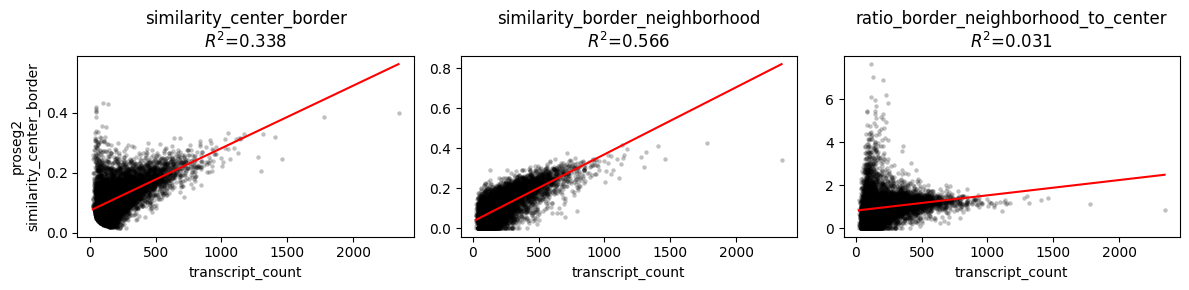

In [14]:
plot_rs_against_counts("transcript_count",
                       ycols=[
                        "similarity_center_border",
                        "similarity_border_neighborhood",
                        "ratio_border_neighborhood_to_center",
                    ])

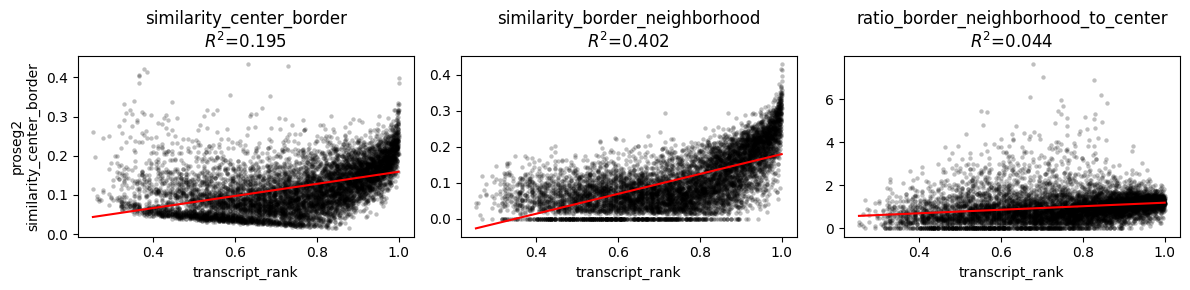

In [15]:
cell_df["transcript_rank"] = cell_df["transcript_count"].rank(pct=True)
plot_rs_against_counts("transcript_rank",
                        ycols=[
                        "similarity_center_border",
                        "similarity_border_neighborhood",
                        "ratio_border_neighborhood_to_center",
                    ])

In [16]:
st.rs.null_corrected_center_border_similarity(n_sim=50, metric="cosine_sim")

,similarity_center_border,similarity_center_border_null_mean,similarity_center_border_null_sd,similarity_center_border_residual,similarity_center_border_zscore,center_counts_used,border_counts_used,n_genes_used,cell_id
0,0.232602,0.495159,0.033753,-0.262557,-7.778697,328,132,345,1
1,0.061235,0.431907,0.099827,-0.370672,-3.713150,25,11,34,2
2,NaN,NaN,NaN,NaN,NaN,0,1,1,3
3,0.085689,0.461504,0.050398,-0.375816,-7.456937,92,35,106,4
4,NaN,NaN,NaN,NaN,NaN,41,3,41,5
...,...,...,...,...,...,...,...,...,...
17542,NaN,NaN,NaN,NaN,NaN,0,0,0,17881
17543,NaN,NaN,NaN,NaN,NaN,1,2,2,17882
17544,NaN,NaN,NaN,NaN,NaN,27,4,29,17883
17545,NaN,NaN,NaN,NaN,NaN,13,9,21,17884


In [17]:
features = ['similarity_center_border', 'similarity_center_border_null_mean', 'similarity_center_border_null_sd', 'similarity_center_border_residual', 'similarity_center_border_zscore', 'transcript_count']
cell_df = []
obs = sdata.tables['table'].obs[features].copy()
obs['sample'] = "proseg2"
cell_df.append(obs)
cell_df = pd.concat(cell_df)
print(cell_df.shape)
cell_df = cell_df.reset_index(drop=True)
cell_df.head()

(17885, 7)


,similarity_center_border,similarity_center_border_null_mean,similarity_center_border_null_sd,similarity_center_border_residual,similarity_center_border_zscore,transcript_count,sample
0,0.232602,0.495159,0.033753,-0.262557,-7.778697,535.0,proseg2
1,0.061235,0.431907,0.099827,-0.370672,-3.713150,48.0,proseg2
2,NaN,NaN,NaN,NaN,NaN,6.0,proseg2
3,0.085689,0.461504,0.050398,-0.375816,-7.456937,150.0,proseg2
4,NaN,NaN,NaN,NaN,NaN,47.0,proseg2


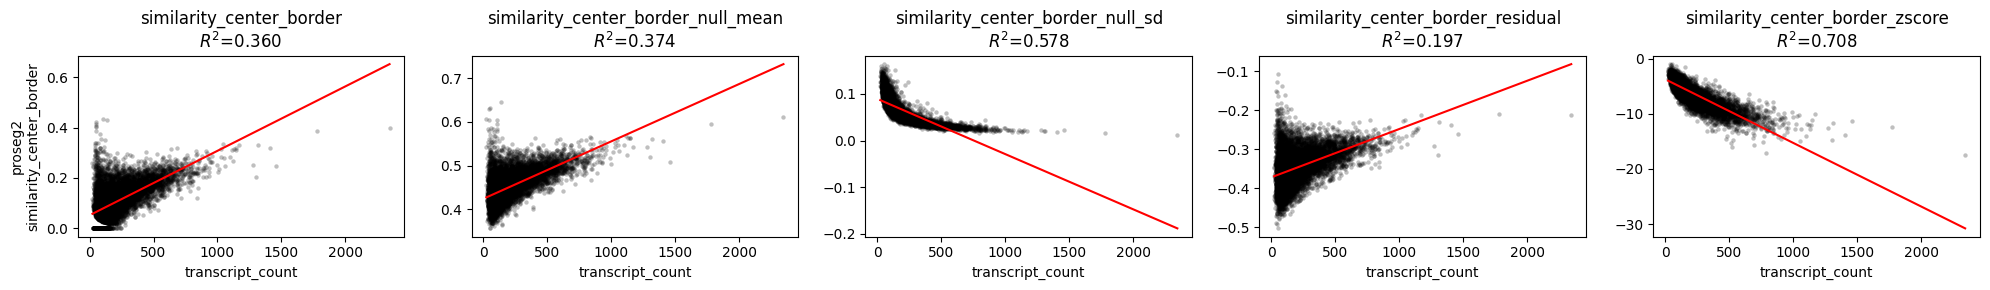

In [18]:
plot_rs_against_counts("transcript_count",
                       ycols=[
                        "similarity_center_border",
                        "similarity_center_border_null_mean",
                        "similarity_center_border_null_sd",
                        "similarity_center_border_residual",
                        "similarity_center_border_zscore",
                    ])

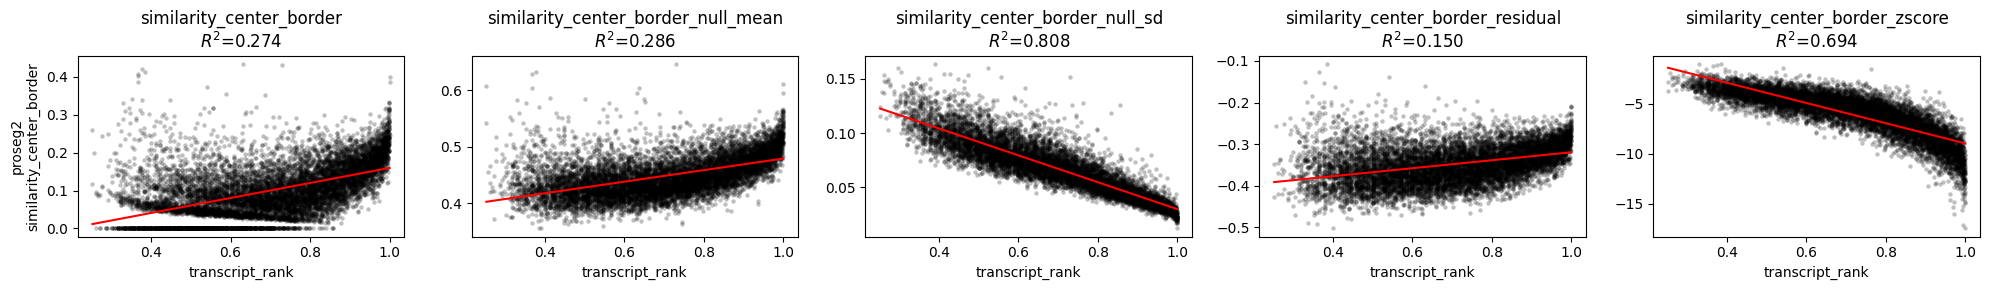

In [19]:
cell_df["transcript_rank"] = cell_df["transcript_count"].rank(pct=True)
plot_rs_against_counts("transcript_rank",
                       ycols=[
                        "similarity_center_border",
                        "similarity_center_border_null_mean",
                        "similarity_center_border_null_sd",
                        "similarity_center_border_residual",
                        "similarity_center_border_zscore",
                    ])

In [20]:
cell_df["similarity_center_border_residual"].mean()

np.float64(-0.34807272938516937)

In [21]:
cell_df["similarity_center_border_residual"].median()

np.float64(-0.34829120785112244)